# ChronoLux Data Analysis & Metrology Visualization

This notebook processes the `.csv` outputs from the ChronoLux simulations (Scenarios A, B, C, and D). It generates intricate, academic-quality graphs designed for IEEE/ACM paper publication.

### General Simulation Parameters
- **Artifact:** Stanford Bunny with 2k texture
- **Environment:** Custom modeled house
- **Sampling Quality:** 64 rays per texel
- **Location / Time:** Latitude 44.427, Longitude 26.103, simulated over the full meteorological year 2026

### Overview of Scenarios
- **Scenario A (Baseline):** Highly exposed position next to a window.
  - Floor: 0.50 Reflectance
  - Windows: 0.08 Reflectance, 0.84 Transmittance (Standard clear glass)
- **Scenario B (Materials Intervention):** Same position, but with protective materials.
  - Floor: 0.15 Reflectance (e.g., dark carpet / matte wood)
  - Windows: 0.12 Reflectance, 0.45 Transmittance (Tinted conservation glass)
- **Scenario C (Positional Optimization):** Artifact moved to a shaded corner, using Baseline materials.
  - Floor: 0.50 Reflectance
  - Windows: 0.08 Reflectance, 0.84 Transmittance
- **Scenario D (Combined Intervention):** Artifact in the shaded corner with the protective materials.
  - Floor: 0.15 Reflectance
  - Windows: 0.12 Reflectance, 0.45 Transmittance

## 0. Install Dependencies
Run this cell once to ensure all required Python libraries are installed in your current environment.

In [41]:
# Install required dependencies for data processing and graphing
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


## 1. Environment Setup
First, we import the necessary scientific computing and visualization libraries. We enforce a high-quality styling standard (`seaborn-v0_8-paper`) to ensure fonts and line weights are print-ready.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import os

# Ensure clean output directory
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# Set high-quality styling for IEEE/ACM papers
plt.style.use('seaborn-v0_8-paper')
sns.set_theme(style="whitegrid", font_scale=1.2)

# Custom color palette for the scenarios to ensure visual distinction
colors = {"Scenario A (Baseline)": "#d62728", # Red
          "Scenario B (Materials)": "#ff7f0e", # Orange
          "Scenario C (Position)": "#1f77b4", # Blue
          "Scenario D (Combined)": "#2ca02c"} # Green

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Loading & Preprocessing
Here we load the `.csv` telemetry data exported from the Unity compute shaders. We convert the `Time` column to Datetime and create a **Daily Resampled Dataframe** (`dfs_daily`). This crucial preprocessing step eliminates high-frequency Monte Carlo noise and prevents "ink bloat" in the macro-scale plots (Cumulative Dose, Variance, Error) by plotting 365 daily aggregates instead of 8760 hourly spikes.

In [43]:
print("Loading CSV data and preprocessing...")
files = {
    "Scenario A (Baseline)": "scenario_a.csv",
    "Scenario B (Materials)": "scenario_b.csv",
    "Scenario C (Position)": "scenario_c.csv",
    "Scenario D (Combined)": "scenario_d.csv"
}

dfs = {}        # Hourly data (for high-res profiling)
dfs_daily = {}  # Daily data (for cleaner macro-scale plots)

for label, filename in files.items():
    df = pd.read_csv(filename)
    df['Time'] = pd.to_datetime(df['Time'])
    # Scale to kLux-Hours for cleaner Y-axis labels
    df['MaxDose_kLux'] = df['MaxDose'] / 1000.0
    df['AvgDose_kLux'] = df['AvgDose'] / 1000.0
    
    dfs[label] = df
    
    # --- Preprocessing: Resample to Daily Frequency ---
    df_set = df.set_index('Time')
    df_daily = df_set.resample('1D').agg({
        'MaxDose_kLux': 'max',        # Cumulative metric: take max of the day
        'AvgDose_kLux': 'max',        # Cumulative metric: take max of the day
        'DoseVariance': 'mean',       # Average contrast stress over the day
        'AvgSensorErrorPct': 'mean',  # Average daily convergence error
        'DeltaMaxDose': 'max',        # Peak hourly hit across that specific day
        'BeamLux': 'mean',
        'DiffuseLux': 'mean'
    }).reset_index()
    dfs_daily[label] = df_daily

print("Data loaded and preprocessed (Hourly & Daily variants created).")

Loading CSV data and preprocessing...
Data loaded and preprocessed (Hourly & Daily variants created).


## 3. Cumulative Light Dosimetry
These line charts prove the core value of the Digital Twin. They show how the cumulative light energy aggregates over the full simulated year. We use the *Daily* dataset to provide smooth, clean trajectory lines free from hourly quantization steps.

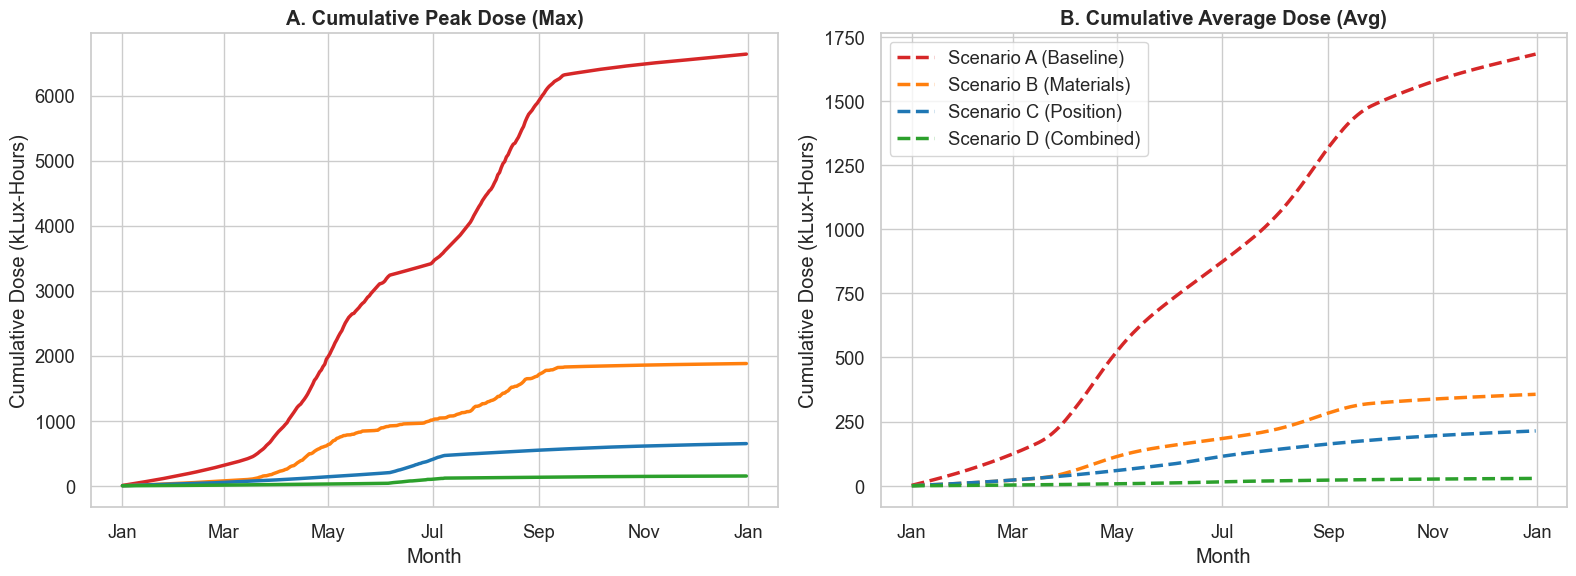

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Max Dose (Daily)
for label, df_d in dfs_daily.items():
    ax1.plot(df_d['Time'], df_d['MaxDose_kLux'], label=label, color=colors[label], linewidth=2.5)
ax1.set_title('A. Cumulative Peak Dose (Max)', fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Cumulative Dose (kLux-Hours)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Graph 2: Avg Dose (Daily)
for label, df_d in dfs_daily.items():
    ax2.plot(df_d['Time'], df_d['AvgDose_kLux'], label=label, color=colors[label], linewidth=2.5, linestyle='--')
ax2.set_title('B. Cumulative Average Dose (Avg)', fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Cumulative Dose (kLux-Hours)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig(f'{output_dir}/fig1_cumulative_dosimetry.png', dpi=300)
plt.show()

## 4. End-of-Year Quantitative Summary
A clean bar chart comparing the final state of all scenarios at December 31st. This is the ultimate "money shot" for the Results section, summarizing the entire simulation.

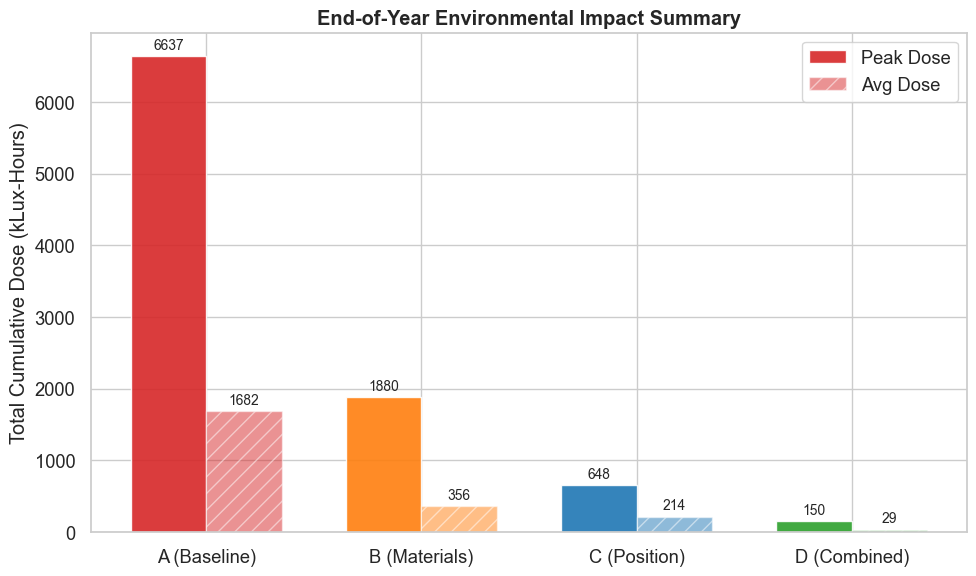

In [47]:
labels = list(dfs_daily.keys())
final_max = [df_d['MaxDose_kLux'].iloc[-1] for df_d in dfs_daily.values()]
final_avg = [df_d['AvgDose_kLux'].iloc[-1] for df_d in dfs_daily.values()]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, final_max, width, label='Peak Dose', color=[colors[l] for l in labels], alpha=0.9)
rects2 = ax.bar(x + width/2, final_avg, width, label='Avg Dose', color=[colors[l] for l in labels], alpha=0.5, hatch='//')

ax.set_ylabel('Total Cumulative Dose (kLux-Hours)')
ax.set_title('End-of-Year Environmental Impact Summary', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([l.replace("Scenario ", "") for l in labels])
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.0f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)
autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig(f'{output_dir}/fig2_final_dose_bar.png', dpi=300)
plt.show()

## 5. Structural Stress & Metrological Validation
Here we visualize the **Spatial Dose Variance** and **Sensor Error** using the Daily preprocessed data. 
- High Dose Variance indicates sharp, high-contrast lighting (shadow lines cutting across the artifact). We plot the daily mean to cleanly observe seasonal shifts rather than noisy hour-by-hour sun movement.
- Sensor Error tracks the convergence of the hardware-accelerated Monte Carlo Virtual Sensors compared to theoretical models.

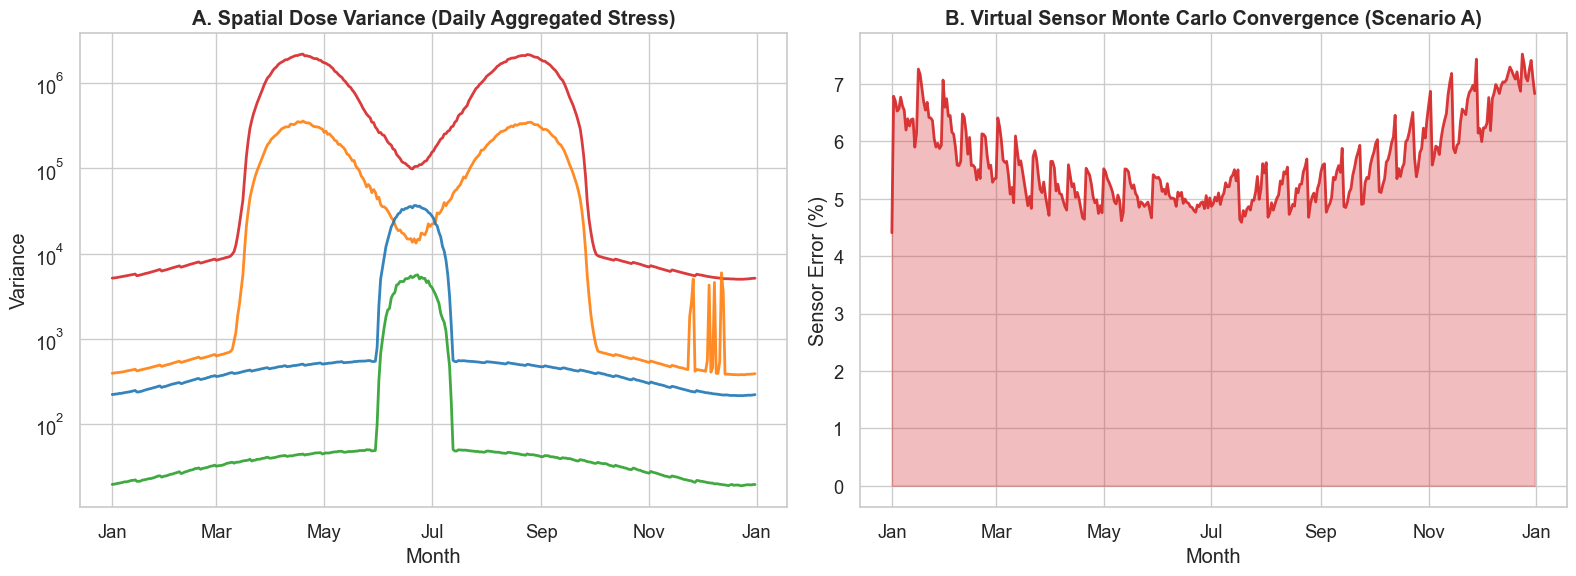

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Dose Variance (Daily Mean)
for label, df_d in dfs_daily.items():
    ax1.plot(df_d['Time'], df_d['DoseVariance'], label=label, color=colors[label], linewidth=2.0, alpha=0.9)
ax1.set_title('A. Spatial Dose Variance (Daily Aggregated Stress)', fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Variance')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax1.set_yscale('log') # Log scale helps view massive variance differences

# Graph 2: Hardware Sensor Convergence Error (Scenario A - Daily Mean)
df_a_d = dfs_daily["Scenario A (Baseline)"]
ax2.plot(df_a_d['Time'], df_a_d['AvgSensorErrorPct'], color=colors["Scenario A (Baseline)"], linewidth=2.0, alpha=0.9)
ax2.set_title('B. Virtual Sensor Monte Carlo Convergence (Scenario A)', fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Sensor Error (%)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax2.fill_between(df_a_d['Time'], 0, df_a_d['AvgSensorErrorPct'], color=colors["Scenario A (Baseline)"], alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/fig3_stress_and_validation.png', dpi=300)
plt.show()

## 6. Diurnal Solar Profiling (Intricate Temporal Analysis)
This advanced visualization relies on the raw **Hourly** data (pre-aggregation) because it correlates the specific hour of the day with the maximum irradiance hit (`DeltaMaxDose`). We use a Logarithmic Color scale to reveal the gradients of indirect/diffuse light alongside the massive direct beam glare.

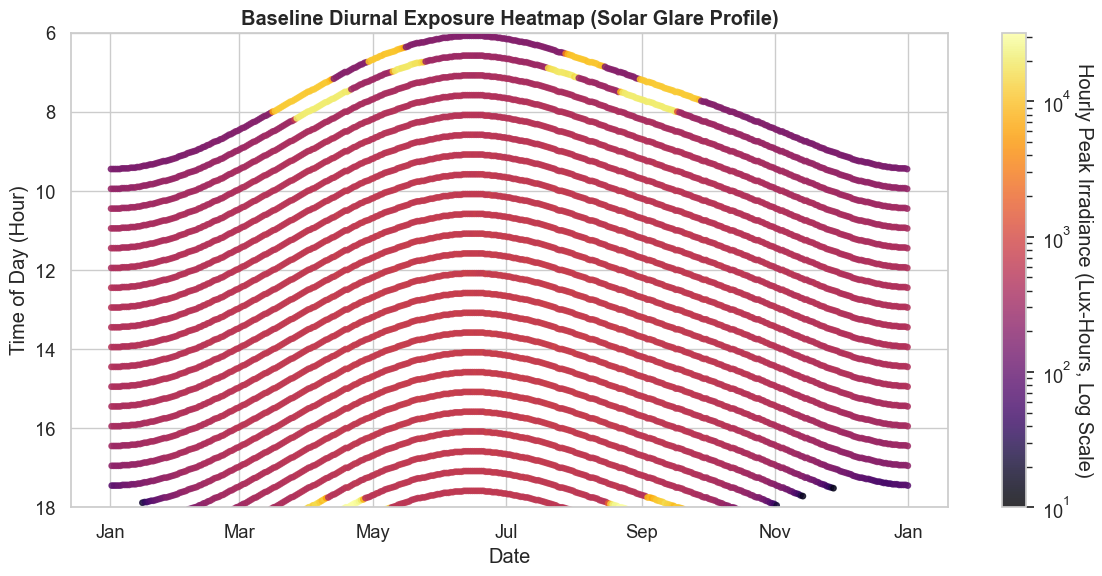

In [50]:
df_a = dfs["Scenario A (Baseline)"]

# Extract hour of day for plotting from the RAW hourly dataset
df_a_day = df_a.copy()
df_a_day['Hour'] = df_a_day['Time'].dt.hour + df_a_day['Time'].dt.minute / 60.0

plt.figure(figsize=(12, 6))

# Filter out very low values so LogNorm doesn't fail, focusing on meaningful exposure
df_plot = df_a_day[df_a_day['DeltaMaxDose'] > 5]

# Scatter plot mapping time of day vs Delta Max Dose, colored using LogNorm to enhance the lower range
scatter = plt.scatter(df_plot['Time'], df_plot['Hour'], 
                      c=df_plot['DeltaMaxDose'], cmap='inferno', 
                      norm=mcolors.LogNorm(vmin=10, vmax=df_plot['DeltaMaxDose'].max()),
                      s=15, alpha=0.8)
cbar = plt.colorbar(scatter)
cbar.set_label('Hourly Peak Irradiance (Lux-Hours, Log Scale)', rotation=270, labelpad=15)

plt.title('Baseline Diurnal Exposure Heatmap (Solar Glare Profile)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Time of Day (Hour)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().invert_yaxis() # Morning at top, afternoon at bottom
plt.ylim(18, 6) # Focus on daylight hours (6 AM to 6 PM)

plt.tight_layout()
plt.savefig(f'{output_dir}/fig4_diurnal_heatmap.png', dpi=300)
plt.show()

## 7. Global Illumination Breakdown (Beam vs. Diffuse)
Also utilizing the high-frequency **Hourly** data, we plot an area chart for the summer solstice week to show the exact breakdown between Direct sunlight (`BeamLux`) and Ambient skylight/bounces (`DiffuseLux`). This physically validates the Next Event Estimation (NEE) system.

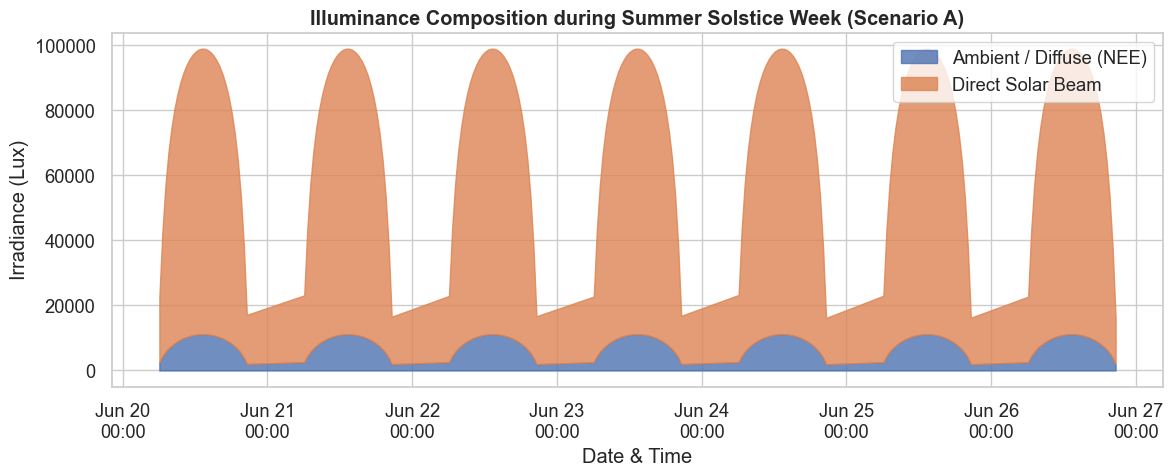

In [51]:
# Filter a specific week (e.g., Summer Solstice in June) from the RAW hourly dataset
mask = (df_a['Time'] >= '2026-06-20') & (df_a['Time'] <= '2026-06-27')
df_week = df_a.loc[mask]

plt.figure(figsize=(12, 5))
plt.fill_between(df_week['Time'], 0, df_week['DiffuseLux'], label='Ambient / Diffuse (NEE)', color='#4c72b0', alpha=0.8)
plt.fill_between(df_week['Time'], df_week['DiffuseLux'], df_week['DiffuseLux'] + df_week['BeamLux'], 
                 label='Direct Solar Beam', color='#dd8452', alpha=0.8)

plt.title('Illuminance Composition during Summer Solstice Week (Scenario A)', fontweight='bold')
plt.xlabel('Date & Time')
plt.ylabel('Irradiance (Lux)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'{output_dir}/fig5_beam_vs_diffuse.png', dpi=300)
plt.show()